In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from stats_can import StatsCan
import matplotlib.ticker as ticker
import matplotlib.dates as mdates



In [2]:

sns.set_theme(font='Arial',style='darkgrid',font_scale=1.2)
plt.style.use('ggplot')

# Define your custom color palette
cmhc_palette = ["#00093A","#de3e33","#483FCD","#999db0","#f4bfbb","#E1E4E7","#b6b2eb","#2b267b","#fbeae8","#b12519"]  # Replace with your hex colors

# Set it globally for seaborn plots
sns.set_palette(cmhc_palette)

In [3]:




# Load StatCan data

sc = StatsCan(data_folder="C:/Users/mmak/Documents/data")
df = sc.table_to_df("36-10-0402-02")
#sc.update_tables("36-10-0402-02")


In [4]:
sk = df[df['GEO']=='Saskatchewan']

In [6]:
sk = sk[(sk['UOM']=='Dollars') & (sk['Prices']=='Chained (2017) dollars')]
sk_pivot = sk.pivot_table(values = 'VALUE',index = 'REF_DATE', columns = 'North American Industry Classification System (NAICS)')
sk_sector =  sk_pivot.loc[:, sk_pivot.columns.str.contains(r"\d{2}(?!\d)")]
sk_sector=sk_pivot.loc[:,sk_pivot.columns.str.contains(r"\[\d{2}\]")]
sk_subsector=sk_pivot.loc[:,sk_pivot.columns.str.contains(r"\[\d{3}\]")]



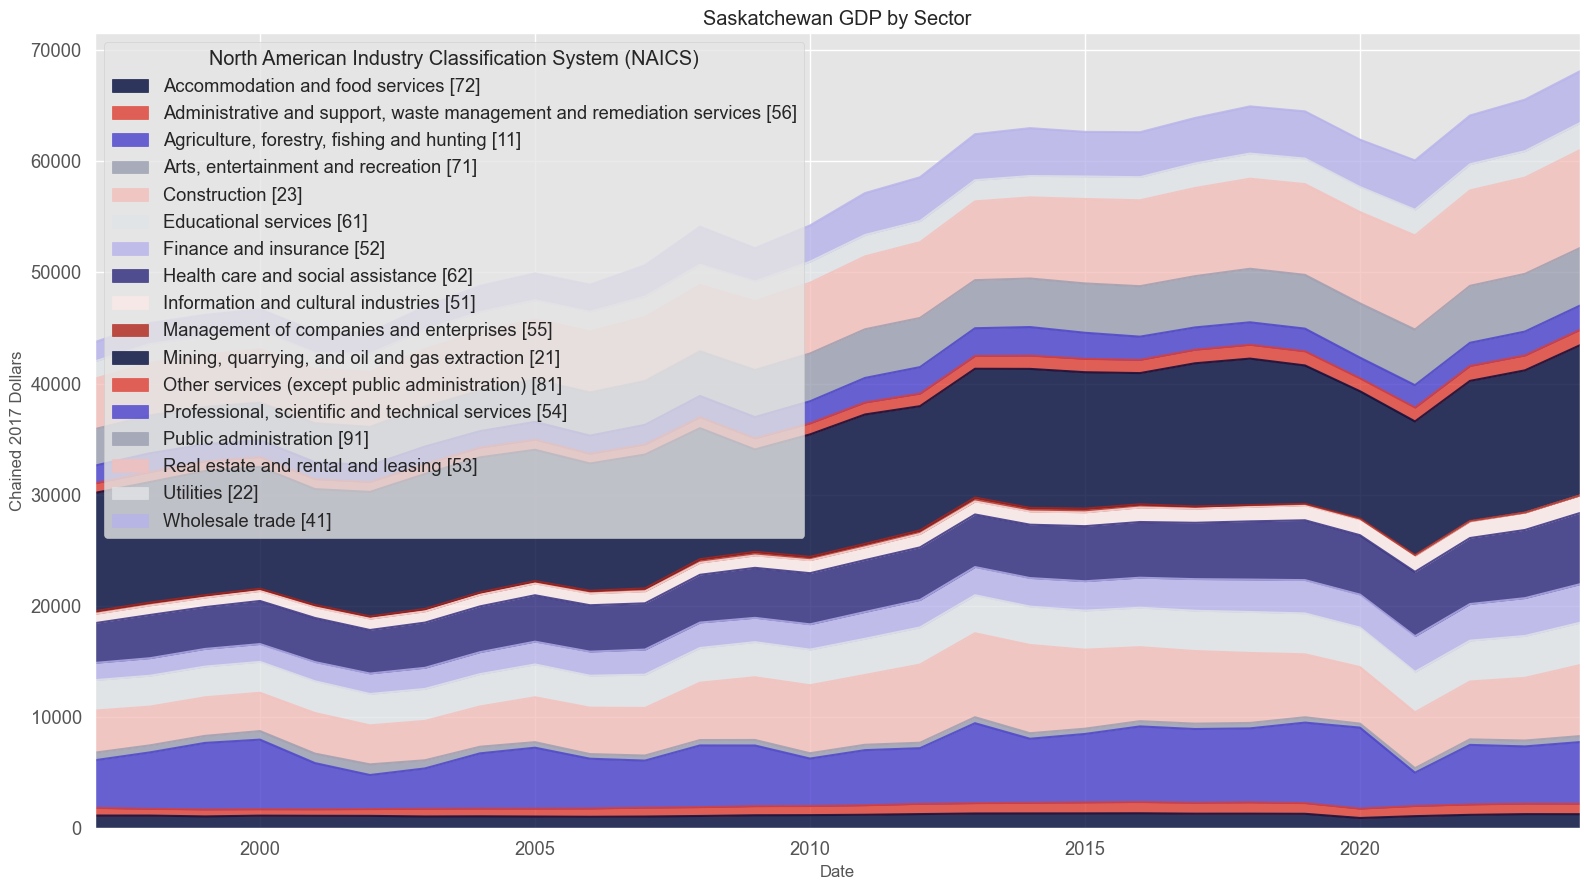

In [7]:
sk_sector.plot.area(stacked=True, alpha=0.8, figsize=(16,9))

plt.title("Saskatchewan GDP by Sector")
plt.ylabel("Chained 2017 Dollars")
plt.xlabel("Date")
plt.tight_layout()
plt.show()


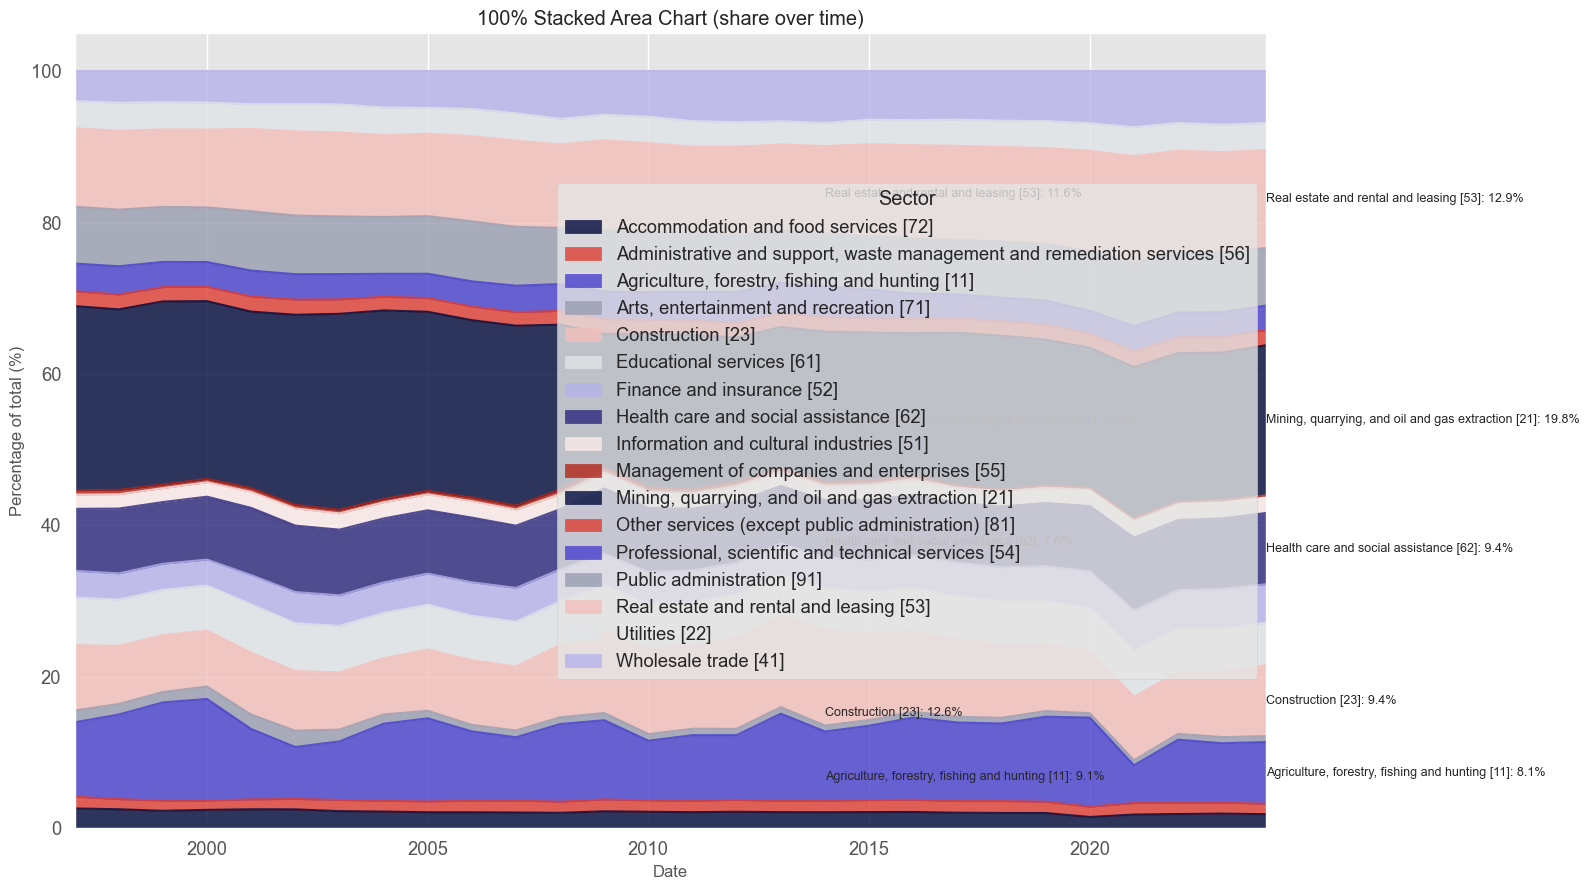

In [8]:
sk_sector_pct = sk_sector.div(sk_sector.sum(axis=1), axis=0) * 100

# Plot as stacked area (100% stacked chart)
ax = sk_sector_pct.plot.area(stacked=True, alpha=0.8, figsize=(16,9))

last_date = sk_sector_pct.index[-1]
mid_date = sk_sector_pct.index[17]

def annotate_top5(date, ax, x_offset=5):
    shares = sk_sector_pct.loc[date].sort_values(ascending=False).head(5)
    cum_sum = sk_sector_pct.loc[sk_sector_pct.index[-1]].cumsum()


    for col in shares.index:
        y_bottom = cum_sum[col] - sk_sector_pct.loc[date, col]
        y_pos = y_bottom + sk_sector_pct.loc[date, col] / 2  # middle of band
        ax.text(
            date + pd.Timedelta(days=x_offset),  # offset outside chart
            y_pos,
            f"{col}: {shares[col]:.1f}%",
            ha="left", va="center", fontsize=9
        )

# Annotate for last and middle date
annotate_top5(last_date, ax)
annotate_top5(mid_date, ax)


plt.title("100% Stacked Area Chart (share over time)")
plt.ylabel("Percentage of total (%)")
plt.xlabel("Date")
plt.legend(title="Sector")
plt.tight_layout()
plt.show()


In [9]:
sk_subsector

North American Industry Classification System (NAICS),Aboriginal public administration [914],Accommodation services [721],Administrative and support services [561],Air transportation [481],Ambulatory health care services [621],"Amusement, gambling and recreation industries [713]",Animal production and aquaculture [112],Beverage and tobacco product manufacturing [312],Broadcasting (except Internet) [515],Building material and garden equipment and supplies dealers [444],...,Support activities for agriculture and forestry [115],"Support activities for mining, and oil and gas extraction [213]",Support activities for transportation [488],Telecommunications [517],Transportation equipment manufacturing [336],Truck transportation [484],Warehousing and storage [493],Waste management and remediation services [562],Water transportation [483],Wood product manufacturing [321]
REF_DATE,,,,,,,,,,,,,,,,,,,,,
1997-01-01,347.4,410.9,685.1,64.4,1269.2,180.3,392.7,62.4,NaN,NaN,...,108.1,704.6,161.7,NaN,123.5,400.8,136.1,23.5,0.7,101.8
1998-01-01,357.2,384.5,586.8,62.9,1343.5,183.9,386.1,49.2,NaN,NaN,...,165.3,715.1,154.4,NaN,134.7,419.0,128.0,30.8,0.1,90.8
1999-01-01,361.9,376.3,603.2,58.5,1268.0,170.5,352.6,37.6,NaN,NaN,...,156.1,526.5,130.1,NaN,124.0,420.4,141.5,35.3,6.0,85.2
2000-01-01,373.3,372.6,542.8,50.6,1337.1,177.6,448.1,54.4,NaN,NaN,...,150.3,668.4,130.9,NaN,134.9,531.5,167.5,38.5,5.9,85.7
2001-01-01,392.3,377.3,541.1,37.5,1434.9,185.2,443.3,61.3,NaN,NaN,...,159.7,716.8,126.9,NaN,155.1,596.0,157.4,44.0,5.9,69.5
2002-01-01,394.9,389.9,548.5,34.9,1387.4,179.2,469.9,28.8,NaN,NaN,...,159.3,654.7,147.5,NaN,129.1,605.0,120.5,57.2,4.6,77.7
2003-01-01,426.4,408.4,625.8,31.6,1425.3,187.1,529.7,27.9,NaN,NaN,...,169.1,741.5,162.9,NaN,125.6,599.8,115.7,66.3,4.6,107.1
2004-01-01,442.2,404.3,617.1,35.3,1487.3,195.1,696.1,28.8,NaN,NaN,...,155.4,668.1,148.2,NaN,122.8,580.3,151.6,72.1,5.8,186.8
2005-01-01,460.1,401.9,632.5,39.6,1494.2,199.0,716.9,31.9,NaN,NaN,...,150.4,860.7,112.8,NaN,147.7,628.5,178.7,72.4,6.1,204.8


In [13]:
sk_subsector.loc[:,sk_subsector.columns.str.contains('21')]

North American Industry Classification System (NAICS),Accommodation services [721],Ambulatory health care services [621],Mining and quarrying (except oil and gas) [212],Monetary authorities - central bank [521],Oil and gas extraction [211],"Support activities for mining, and oil and gas extraction [213]",Wood product manufacturing [321]
REF_DATE,,,,,,,
1997-01-01,410.9,1269.2,4267.3,1.5,5894.0,704.6,101.8
1998-01-01,384.5,1343.5,4159.0,1.3,6255.4,715.1,90.8
1999-01-01,376.3,1268.0,4330.2,0.0,6790.7,526.5,85.2
2000-01-01,372.6,1337.1,4738.6,0.1,6081.0,668.4,85.7
2001-01-01,377.3,1434.9,4207.3,0.0,5864.7,716.8,69.5
2002-01-01,389.9,1387.4,4445.1,0.0,6490.6,654.7,77.7
2003-01-01,408.4,1425.3,4957.5,0.0,6929.0,741.5,107.1
2004-01-01,404.3,1487.3,5560.8,0.0,6726.6,668.1,186.8
2005-01-01,401.9,1494.2,5093.5,0.0,6522.5,860.7,204.8


In [14]:
sk_subsector.loc[:,sk_subsector.columns.str.contains('11')]

North American Industry Classification System (NAICS),Animal production and aquaculture [112],Crop production [111],Farm product merchant wholesalers [411],Federal government public administration [911],"Fishing, hunting and trapping [114]",Food manufacturing [311],Forestry and logging [113],Oil and gas extraction [211],Publishing industries [511],Repair and maintenance [811],Support activities for agriculture and forestry [115]
REF_DATE,,,,,,,,,,,
1997-01-01,392.7,6086.6,NaN,1040.9,17.9,391.9,144.9,5894.0,182.1,264.6,108.1
1998-01-01,386.1,7292.6,NaN,1034.9,25.7,507.2,200.5,6255.4,164.7,285.0,165.3
1999-01-01,352.6,9302.3,NaN,951.8,9.4,330.7,246.2,6790.7,141.4,303.0,156.1
2000-01-01,448.1,9215.0,NaN,912.6,10.7,424.0,205.6,6081.0,136.4,306.5,150.3
2001-01-01,443.3,4002.4,NaN,980.5,15.1,395.2,214.0,5864.7,135.0,311.8,159.7
2002-01-01,469.9,1842.0,NaN,988.0,15.1,359.3,271.6,6490.6,153.1,314.2,159.3
2003-01-01,529.7,2386.9,NaN,1014.2,12.5,360.1,242.8,6929.0,138.8,327.4,169.1
2004-01-01,696.1,3790.6,NaN,1038.6,4.5,347.7,94.2,6726.6,136.0,321.8,155.4
2005-01-01,716.9,4520.7,NaN,1055.1,5.4,427.1,61.8,6522.5,124.3,347.9,150.4
